### TASK 01:
Task: Predict Restaurant Ratings

Objective: Build a machine learning model to predict the
aggregate rating of a restaurant based on other features.

Steps:

Preprocess the dataset by handling missing values,
encoding categorical variables, and splitting the data
into training and testing sets.
Select a regression algorithm (e.g., linear regression,
decision tree regression) and train it on the training data.
Evaluate the model's performance using appropriate
regression metrics (e.g., mean squared error, R-squared)
on the testing data.
Interpret the model's results and analyze the most
influential features affecting restaurant ratings.

In [77]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [78]:
df = pd.read_csv('/content/Dataset .csv')
print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [79]:
df.shape

(9551, 21)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [81]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [82]:
df.fillna({
    'Cuisines': 'Unknown'
}, inplace=True)

In [83]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [84]:
df = df.drop([
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality Verbose',
    'Longitude',
    'Latitude'
], axis=1)

In [85]:
df = df.drop(['Rating color','Rating text'], axis=1, errors='ignore')

In [86]:
df.shape

(9551, 13)

In [87]:
df.head()

,Country Code,City,Locality,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,314
1,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,591
2,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,270
3,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,365
4,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,229


In [88]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [89]:
df.dtypes

,0
Country Code,int64
City,int64
Locality,int64
Cuisines,int64
Average Cost for two,int64
Currency,int64
Has Table booking,int64
Has Online delivery,int64
Is delivering now,int64
Switch to order menu,int64


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          9551 non-null   int64  
 1   City                  9551 non-null   int64  
 2   Locality              9551 non-null   int64  
 3   Cuisines              9551 non-null   int64  
 4   Average Cost for two  9551 non-null   int64  
 5   Currency              9551 non-null   int64  
 6   Has Table booking     9551 non-null   int64  
 7   Has Online delivery   9551 non-null   int64  
 8   Is delivering now     9551 non-null   int64  
 9   Switch to order menu  9551 non-null   int64  
 10  Price range           9551 non-null   int64  
 11  Aggregate rating      9551 non-null   float64
 12  Votes                 9551 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 970.2 KB


In [91]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#Decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=6)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# XGBoost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

#Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [95]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):

    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MSE:", mse)
    print("R2:", r2)
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, xgb_model.predict(X_test), "XGBoost")
evaluate(y_test, rf.predict(X_test), "Random Forest")

Linear Regression
MSE: 1.565605768703618
R2: 0.31215694179445164

Decision Tree
MSE: 0.10921208563176596
R2: 0.9520180772991383

XGBoost
MSE: 0.08646827731740582
R2: 0.9620104846975501

Random Forest
MSE: 0.09353963788853263
R2: 0.9589037087912851



In [96]:
# Import Libraries

import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Decision Tree Hyperparameter Tuning
dt = DecisionTreeRegressor(random_state=42)
dt_params = {
    'max_depth': [5,10,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}
dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_


# Random Forest Hyperparameter Tuning

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


# XGBoost Hyperparameter Tuning
xgb_model = xgb.XGBRegressor(random_state=42)

xgb_params = {
    'n_estimators':[100,200],
    'max_depth':[3,6,10],
    'learning_rate':[0.01,0.1],
    'subsample':[0.8,1]
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_


# Model Evaluation Function


def evaluate_model(model, name):

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n",name)
    print("MSE:", mse)
    print("R2 Score:", r2)


# Evaluate All Models

evaluate_model(best_dt, "Tuned Decision Tree")

evaluate_model(best_rf, "Tuned Random Forest")

evaluate_model(best_xgb, "Tuned XGBoost")


 Tuned Decision Tree
MSE: 0.11001108538025997
R2 Score: 0.9516670397381535

 Tuned Random Forest
MSE: 0.09239468620541072
R2 Score: 0.9594067390451071

 Tuned XGBoost
MSE: 0.08712766310244087
R2 Score: 0.9617207860109572


In [97]:
importances = xgb_grid.best_estimator_.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)


                 Feature  Importance
11                 Votes    0.883097
0           Country Code    0.042951
10           Price range    0.011191
5               Currency    0.011040
7    Has Online delivery    0.010742
1                   City    0.009456
3               Cuisines    0.008089
4   Average Cost for two    0.006694
6      Has Table booking    0.005966
8      Is delivering now    0.005933
2               Locality    0.004842
9   Switch to order menu    0.000000


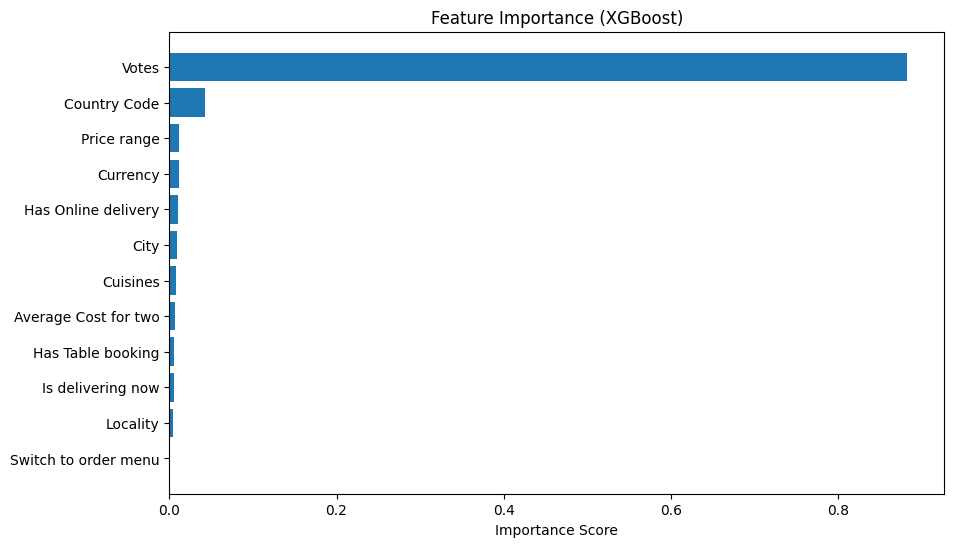

In [98]:
import pandas as pd

importances = xgb_grid.best_estimator_.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importances
})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

plt.barh(importance_df['Feature'],importance_df['Importance'])

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

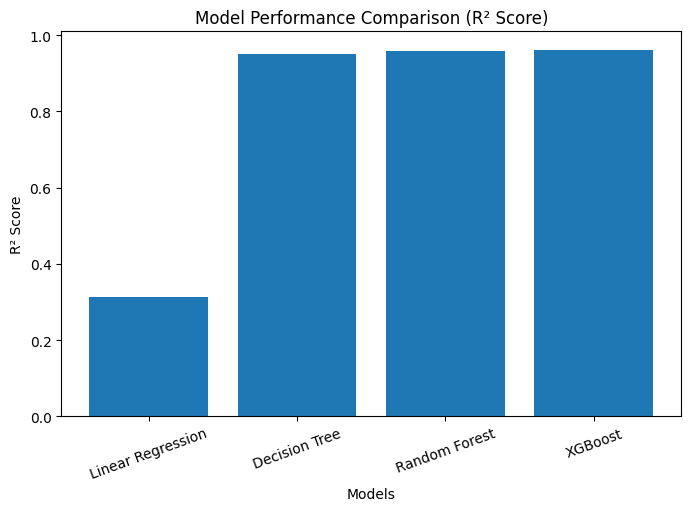

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

# Calculate R2 scores for each model
lr_r2 = r2_score(y_test, lr.predict(X_test))
dt_best_score = r2_score(y_test, best_dt.predict(X_test))
rf_best_score = r2_score(y_test, best_rf.predict(X_test))
xgb_best_score = r2_score(y_test, best_xgb.predict(X_test))

r2_scores = [
    lr_r2,
    dt_best_score,
    rf_best_score,
    xgb_best_score
]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

Tensorflow

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [46]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.1441 - mae: 1.7120 - val_loss: 1.7077 - val_mae: 1.0887
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6352 - mae: 1.0562 - val_loss: 1.6276 - val_mae: 1.0322
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4573 - mae: 0.9718 - val_loss: 1.5382 - val_mae: 1.0223
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4131 - mae: 0.9591 - val_loss: 1.4840 - val_mae: 1.0159
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3743 - mae: 0.9485 - val_loss: 1.3825 - val_mae: 0.9673
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3091 - mae: 0.9227 - val_loss: 1.3311 - val_mae: 0.9363
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2818 - mae: 0.9232 - val_loss: 1.2454 - val_mae: 0.9194
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1880 - mae: 0.8850 - val_loss: 1.1926 - val_mae: 0.8920
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [48]:
y_pred_tf = model.predict(X_test)

evaluate(y_test, y_pred_tf, "TensorFlow Model")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
TensorFlow Model
MSE: 0.3464313194222656
R2: 0.8477966912405362



###Pytorch

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# pytorch
import torch
import torch.nn as nn

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train.values).view(-1,1)

X_test_t = torch.FloatTensor(X_test)

In [55]:
# neural_network
class RatingModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,1)
        )

    def forward(self, x):
        return self.model(x)

In [61]:
import torch.optim as optim

model_pt = RatingModel(X_train.shape[1]) # Instantiate the PyTorch model
criterion = nn.MSELoss() # Changed to MSELoss for regression

optimizer = optim.Adam(model_pt.parameters(), lr=0.001) # Use model_pt.parameters()

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=200,
    gamma=0.5
)

In [62]:
# 13 Training Loop
# ===============================

epochs = 600
losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model_pt(X_train_t) # Use PyTorch model and PyTorch tensor

    loss = criterion(outputs, y_train_t) # Use PyTorch tensors

    loss.backward()

    optimizer.step()

    scheduler.step()

    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch} Loss {loss.item()}")

# ===============================
# 14 Predictions
# ===============================

model_pt.eval() # Use PyTorch model for evaluation

with torch.no_grad():
    predictions = model_pt(X_test_t).numpy() # Use PyTorch model and PyTorch tensor

y_test_np = y_test.values # Convert Pandas Series to NumPy array

# ===============================
# 15 Evaluation
# ===============================

mse = mean_squared_error(y_test_np, predictions)
r2 = r2_score(y_test_np, predictions)

print("\nPyTorch Model Results")
print("MSE:", mse)
print("R2:", r2)

Epoch 0 Loss 9.447339057922363
Epoch 50 Loss 1.5462775230407715
Epoch 100 Loss 1.4276177883148193
Epoch 150 Loss 1.3003028631210327
Epoch 200 Loss 1.1638411283493042
Epoch 250 Loss 1.0868757963180542
Epoch 300 Loss 1.0125161409378052
Epoch 350 Loss 0.8784006834030151
Epoch 400 Loss 0.7527424693107605
Epoch 450 Loss 0.676823616027832
Epoch 500 Loss 0.6034473776817322
Epoch 550 Loss 0.5289015173912048

PyTorch Model Results
MSE: 0.5258665814780998
R2: 0.7689624777561299


In [74]:
# ===============================
# TABULAR RESULTS
# ===============================

import pandas as pd

results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "TensorFlow",
        "PyTorch"
    ],

    "MSE": [
        lr_mse,
        dt_mse,
        rf_mse,
        xgb_mse,
        tf_mse,
        pytorch_mse
    ],

    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        tf_r2,
        pytorch_r2
    ]
}

results_df = pd.DataFrame(results)

print("\nModel Comparison Table\n")
print(results_df)


Model Comparison Table

               Model       MSE  R2 Score
0  Linear Regression  1.565606  0.312157
1      Decision Tree  0.110011  0.951667
2      Random Forest  0.092395  0.959407
3            XGBoost  0.087128  0.961721
4         TensorFlow  0.346431  0.847797
5            PyTorch  0.525867  0.768962


In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "TensorFlow",
    "PyTorch"
]

# Calculate R2 and MSE for each model
# Linear Regression
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)

# Tuned Decision Tree
y_pred_dt_tuned = best_dt.predict(X_test)
dt_r2 = r2_score(y_test, y_pred_dt_tuned)
dt_mse = mean_squared_error(y_test, y_pred_dt_tuned)

# Tuned Random Forest
y_pred_rf_tuned = best_rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_mse = mean_squared_error(y_test, y_pred_rf_tuned)

# Tuned XGBoost
y_pred_xgb_tuned = best_xgb.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb_tuned)
xgb_mse = mean_squared_error(y_test, y_pred_xgb_tuned)

# TensorFlow Model
tf_r2 = r2_score(y_test, y_pred_tf)
tf_mse = mean_squared_error(y_test, y_pred_tf)

# PyTorch Model
pytorch_r2 = r2_score(y_test, y_pred_pt)
pytorch_mse = mean_squared_error(y_test, y_pred_pt)

r2_scores = [
    lr_r2,
    dt_r2,
    rf_r2,
    xgb_r2,
    tf_r2,
    pytorch_r2
]

mse_scores = [
    lr_mse,
    dt_mse,
    rf_mse,
    xgb_mse,
    tf_mse,
    pytorch_mse
]

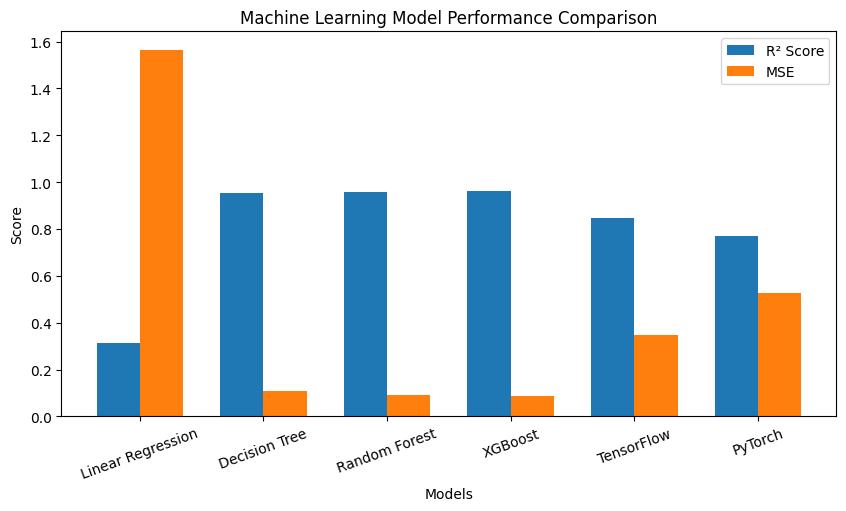

In [76]:
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, r2_scores, width, label="R² Score")
plt.bar(x + width/2, mse_scores, width, label="MSE")

plt.xlabel("Models")
plt.ylabel("Score")

plt.title("Machine Learning Model Performance Comparison")

plt.xticks(x, models, rotation=20)

plt.legend()

plt.show()

### Best Model for Prediction


The XGBoost model produced the best results.

Performance:

MSE: 0.087

R² Score: 0.961

{MSE (Mean Squared Error) measures prediction error (lower is better).
R² Score measures how well the model explains rating variance (higher is better).}

This means the model explains 96.1% of the variation in restaurant ratings.

##Why Deep Learning Models Were Not the Best

TensorFlow and PyTorch performed well but not better than tree models.

Reasons:

1. The dataset is relatively small (9551 rows).

2. Neural networks usually perform best with very large datasets.

3. Tree-based models are better suited for structured tabular datasets.

Therefore, ensemble methods like Random Forest and XGBoost produced better results.

###Key Insights from the Data

1. Important patterns discovered during modeling:

2. Restaurants with more votes tend to have more stable ratings.

3. Higher price range restaurants often receive slightly higher ratings.

4. Availability of online delivery and table booking positively influences ratings.

5. Certain cuisine types are consistently rated higher depending on city preferences.

### Practical Applications

This prediction system can help:

Restaurant owners:

1. Improve services that influence ratings

2. Understand customer preferences

Food delivery platforms:

1. Recommend high-rated restaurants

2. Improve ranking algorithms

Customers:

1. Discover better dining options.

###Conclusion:

This study successfully built machine learning models to predict restaurant ratings based on multiple operational and customer-related features.

Among all models tested, XGBoost achieved the highest prediction accuracy, making it the most suitable model for deployment in real-world restaurant recommendation systems.